In [1]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../..', 'src'))
sys.path.insert(0, src_dir)

from population_model import FNSPopulations

/home/brendan/OneDrive/Masters/Code/Vortices/Julia/DistributedVisualCortex/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
num_exc_neurons = (50, 50)
num_inh_neurons = np.prod(num_exc_neurons)//4
FNSnet = FNSPopulations(num_exc_neurons, num_inh_neurons)
FNSnet.to_dict()

AttributeError: 'Delta' object has no attribute 'to_dict'

In [3]:
if np.product(FNSnet.E.size) <= 100:
    E2E = FNSnet.E2E.conn.require("conn_mat")
    I2E = FNSnet.I2E.conn.require("conn_mat")
    E2I = FNSnet.E2I.conn.require("conn_mat")
    I2I = FNSnet.I2I.conn.require("conn_mat")
    fullconn = np.block([
    [E2E, E2I],  # Top row: E->E and E->E
    [I2E, I2I]   # Bottom row: I->E and I->I
    ])
    positions = np.concatenate((FNSnet.E.positions, FNSnet.I.positions))

    G = nx.from_numpy_array(fullconn, create_using=nx.DiGraph())
    nx.draw(
        G,
        pos=positions,
        connectionstyle="arc3,rad=0.5",
        node_color="b",
        edge_color="b",
        node_size=20,
        width=0.5,
    )

In [4]:
T = 100.0
FNSnet.stimulus = bp.dyn.PoissonInput(FNSnet.Ein.input, np.prod(FNSnet.E.size), 50.0, 1.0)
runner = bp.DSRunner(
    FNSnet,
    monitors=["E.spike", "I.spike", "E.V", "I.V"],
    jit = True
)
runner.run(T)
t = runner.mon["ts"].view()  # [1000:]
X = runner.mon["E.spike"].view()  # [1000:]
Ve = runner.mon["E.V"].view()  # [1000:]
Vi = runner.mon["I.V"].view()  # [1000:]

Predict 1000 steps: : 100%|██████████| 1000/1000 [00:01<00:00, 507.66it/s]


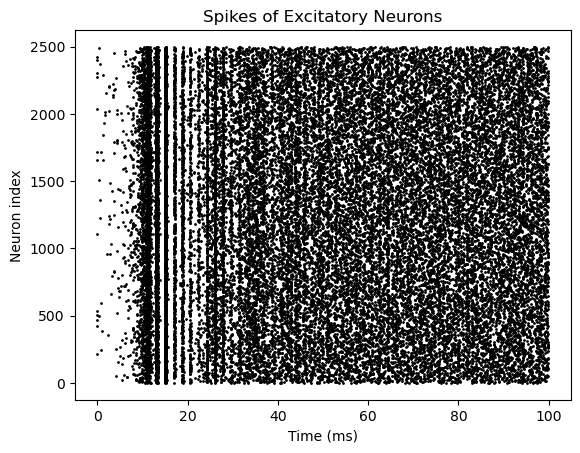

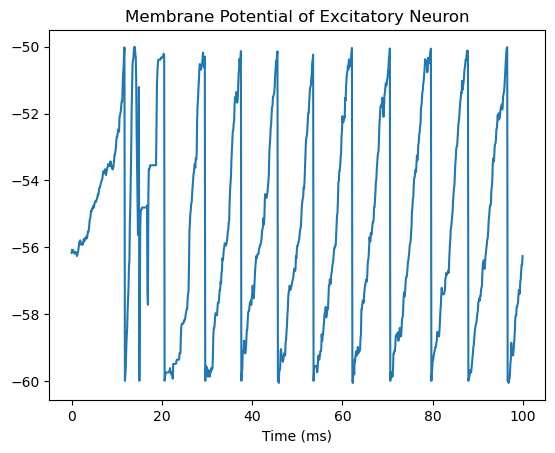

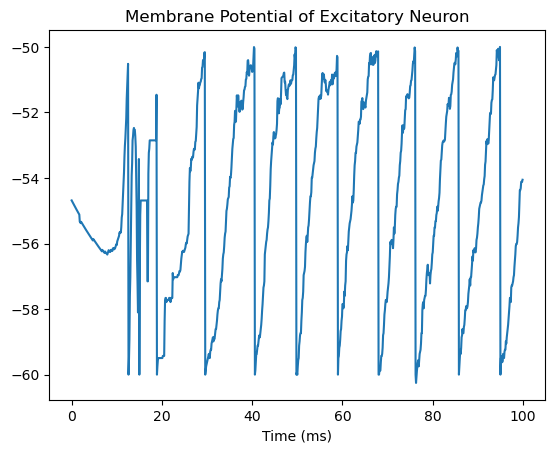

In [5]:
bp.visualize.raster_plot(t, X, title="Spikes of Excitatory Neurons", show=True)
bp.visualize.line_plot(t, Ve[:, 2], title="Membrane Potential of Excitatory Neuron", show=True)
bp.visualize.line_plot(t, Vi[:, 2], title="Membrane Potential of Excitatory Neuron", show=True)